# 🛡️ Compliance Prediction Pipeline
## Scenario 1 — Which Accounts / Markets are Likely to Have Recurring Non-Compliance in 2026 Q2?

---
**Pipeline:** `Business Objective` → `Data Access` → `Data Quality` → `EDA` → `Preprocess` → `Model` → `Eval` → `Deploy`

---
> **Design Decisions:**
> - **Rolling Window** approach ensures zero data leakage between features and labels
> - **Stratified 80/20** split preserves class distribution across train and test
> - **Stratified 5-Fold CV** used during model comparison for reliable performance estimates


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 📌 STAGE 1 — Business Objective

| Item | Detail |
|---|---|
| **Problem Statement** | Predict which accounts (and markets) will have recurring non-compliance in 2026 Q2 |
| **Target Variable** | `recurring = 1` if account appeared in target quarter, else `0` |
| **Approach** | Rolling window classification — features from history before T, label from quarter T |
| **Split Strategy** | Stratified 80/20 train/test + Stratified 5-Fold Cross Validation |
| **Prediction Target** | 2026 Q2 |
| **Granularity** | Account level → rolled up to Market level |
| **Success Metrics** | F1 ≥ 0.50, ROC AUC ≥ 0.80 |


---
## 📂 STAGE 2 — Data Access
Load raw audit observations and preview structure.


In [41]:
# ══ STAGE 2: DATA ACCESS ═══════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = '/content/drive/MyDrive/Prediction_Actual_DataFrame/Observation List New.xlsx'
df_raw = pd.read_excel(FILE_PATH)

print(f"✅ Loaded  → {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Columns → {list(df_raw.columns)}")
print(f"   FQ Range→ {sorted(df_raw['FQ'].dropna().unique())}")
df_raw.head()


✅ Loaded  → 3,251 rows × 15 columns
   Columns → ['Group', 'Market', 'Country', 'FQ', 'Review Name', 'Account', 'Platform', 'Process', 'Domain Area', 'Domain Area Specifics', 'Obs Status', 'Observation', 'Review Status', 'Category', 'InspectionTeam']
   FQ Range→ ['2024 Q1', '2024 Q2', '2024 Q3', '2024 Q4', '2025 Q1', '2025 Q2', '2025 Q3', '2025 Q4', '2026 Q1']


,Group,Market,Country,FQ,Review Name,Account,Platform,Process,Domain Area,Domain Area Specifics,Obs Status,Observation,Review Status,Category,InspectionTeam
0,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,NaN,Account Governance,Other,Other,Completed,The services provided by Kyndryl were not accu...,Completed,Delivery,Japan Inspections Team
1,Japan,Japan,Japan,2026 Q1,Consulting Session for Orico account (SYSOP co...,Orico,Multiple Platforms,Account Governance,Policy Management,Policy Inaccuracy,Completed,Scope for antivirus software were not clearly ...,Completed,Delivery,Japan Inspections Team
2,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Linux,Account Governance,Other,Other,Deemed Accepted,"For Unix environment, 2024 Initial HC remed...",Completed,Delivery,EU Inspections Team
3,SMG,ALPS,ALPS,2026 Q1,Mayr-Melnhof TTCR,Mayr-Melnhof,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"Per Risk RK0021114 opened for ""Healthcheck rem...",Completed,Delivery,EU Inspections Team
4,SMG,ALPS,CHAT,2026 Q1,CHAT Portfolio Inspection,Swiss Re,Multiple Platforms,Account Governance,Other,Other,Deemed Accepted,"\n\nFeb 2025 ""Exception-Both-E U-C HAT-SwissR...",Completed,Delivery,EU Inspections Team


---
## 🔍 STAGE 3 — Data Quality

| Check | Description |
|---|---|
| **Missing Values** | Null counts per column |
| **Sanity Check** | Detect & remove future-dated quarters (2026 Q2/Q3/Q4) |
| **Outliers** | High-volume accounts detected via IQR method |
| **Standards / MIF** | Enforce valid quarter range before modelling |


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.1  MISSING VALUES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                       Count  Pct %
Review Name              583  17.93
Platform                1971  60.63
Domain Area Specifics      1   0.03
InspectionTeam          1292  39.74

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.2  SANITY CHECK — FUTURE-DATED ROWS (should not exist)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  Future-dated rows found : 0
Series([], )
→  These will be EXCLUDED from all modelling.

✅ Clean rows : 3,251  |  Unique accounts : 379  |  Markets : 28

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.4  OUTLIERS — High-volume accounts (IQR method)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Q1=1  Q3=11  IQR=10  Upper Bound=26.0
   Outlier accounts : 24
                                                                           Account  obs_count
                     

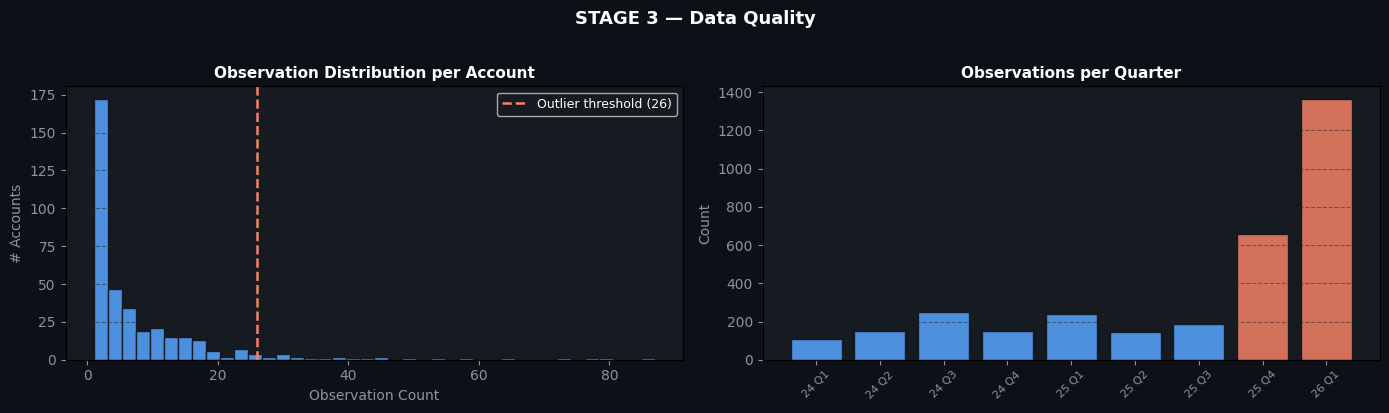


✅ Data Quality checks complete.


In [42]:
# ══ STAGE 3: DATA QUALITY ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

# ── 3.1 Missing Values ────────────────────────────────────────────────────────
print("━" * 58)
print("3.1  MISSING VALUES")
print("━" * 58)
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct %': pct})
print(miss_df[miss_df['Count'] > 0].to_string())

# ── 3.2 Sanity Check: Future Quarters ────────────────────────────────────────
print("\n" + "━" * 58)
print("3.2  SANITY CHECK — FUTURE-DATED ROWS (should not exist)")
print("━" * 58)
FUTURE_QS = ['2026 Q2', '2026 Q3', '2026 Q4']
future_rows = df_raw[df_raw['FQ'].isin(FUTURE_QS)]
print(f"⚠️  Future-dated rows found : {len(future_rows)}")
print(future_rows['FQ'].value_counts().to_string())
print("→  These will be EXCLUDED from all modelling.")

# ── 3.3 Enforce Standards: Valid quarters only ────────────────────────────────
VALID_QS = ['2024 Q1','2024 Q2','2024 Q3','2024 Q4',
            '2025 Q1','2025 Q2','2025 Q3','2025 Q4','2026 Q1']
df = df_raw[df_raw['FQ'].isin(VALID_QS)].copy()
print(f"\n✅ Clean rows : {len(df):,}  |  Unique accounts : {df['Account'].nunique()}  |  Markets : {df['Market'].nunique()}")

# ── 3.4 Outlier Detection: IQR on observation count per account ───────────────
print("\n" + "━" * 58)
print("3.4  OUTLIERS — High-volume accounts (IQR method)")
print("━" * 58)
acc_obs   = df.groupby('Account').size().reset_index(name='obs_count')
Q1v, Q3v  = acc_obs['obs_count'].quantile([0.25, 0.75])
IQR_val   = Q3v - Q1v
upper_lim = Q3v + 1.5 * IQR_val
outlier_accs = acc_obs[acc_obs['obs_count'] > upper_lim]
print(f"   Q1={Q1v:.0f}  Q3={Q3v:.0f}  IQR={IQR_val:.0f}  Upper Bound={upper_lim:.1f}")
print(f"   Outlier accounts : {len(outlier_accs)}")
print(outlier_accs.sort_values('obs_count', ascending=False).head(10).to_string(index=False))

# ── 3.5 Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

axes[0].hist(acc_obs['obs_count'], bins=40, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
axes[0].axvline(upper_lim, color='#f78166', linestyle='--', linewidth=1.8,
                label=f'Outlier threshold ({upper_lim:.0f})')
axes[0].set_title('Observation Distribution per Account', color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Observation Count', color='#8b949e')
axes[0].set_ylabel('# Accounts', color='#8b949e')
axes[0].tick_params(colors='#8b949e')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

q_counts  = df['FQ'].value_counts().reindex(VALID_QS, fill_value=0)
bar_cols  = ['#f78166' if v > q_counts.quantile(0.75) else '#58a6ff' for v in q_counts.values]
axes[1].bar(range(len(VALID_QS)), q_counts.values, color=bar_cols, alpha=0.85, edgecolor='#0d1117')
axes[1].set_xticks(range(len(VALID_QS)))
axes[1].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=8)
axes[1].set_title('Observations per Quarter', color='white', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', color='#8b949e')
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 3 — Data Quality', color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print("\n✅ Data Quality checks complete.")


---
## 📊 STAGE 4 — Explore (EDA)

- **DST** — Distribution of accounts and observations across quarters
- **RoI** — Recurrence of Interest: accounts appearing in most quarters
- **Market × Quarter Heatmap** — volume patterns across markets


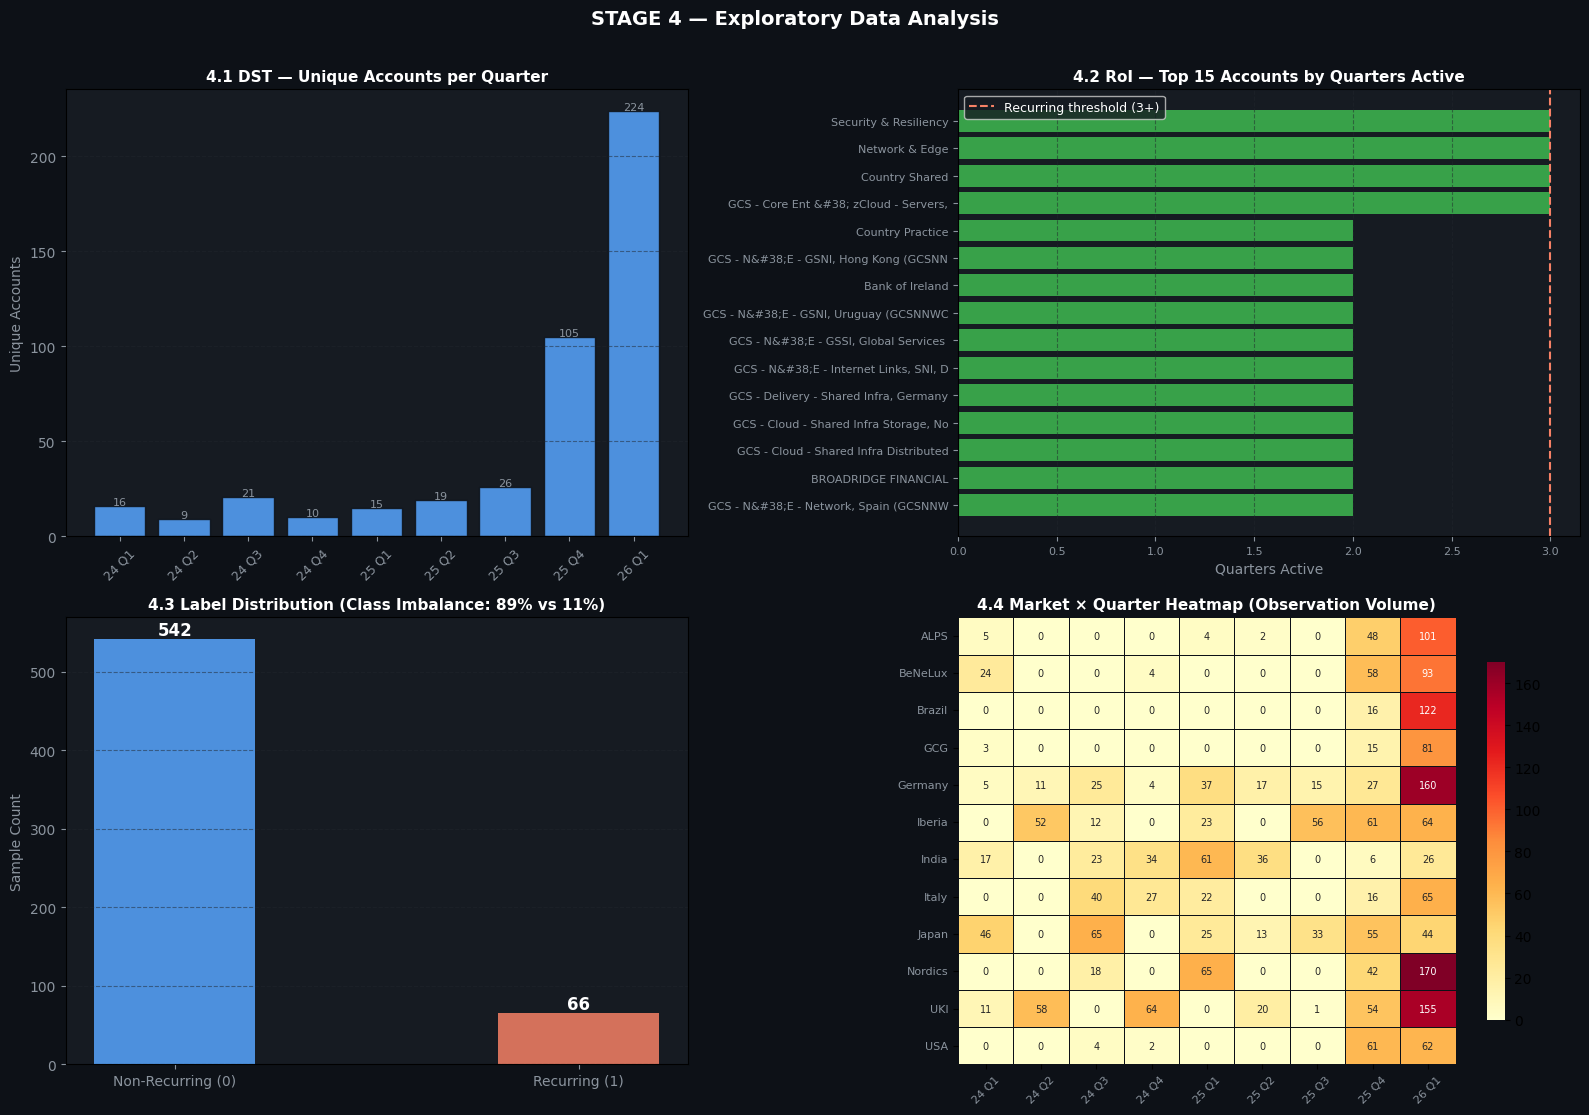

In [43]:
# ══ STAGE 4: EXPLORATORY DATA ANALYSIS ═════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11), facecolor='#0d1117')
for ax in axes.flat: ax.set_facecolor('#161b22')

# ── 4.1 DST: Unique Accounts per Quarter ──────────────────────────────────────
acc_per_q = df.groupby('FQ')['Account'].nunique().reindex(VALID_QS, fill_value=0)
axes[0,0].bar(range(len(VALID_QS)), acc_per_q.values, color='#58a6ff', alpha=0.85, edgecolor='#0d1117')
for i, v in enumerate(acc_per_q.values):
    axes[0,0].text(i, v + 0.5, str(v), ha='center', color='#8b949e', fontsize=8)
axes[0,0].set_xticks(range(len(VALID_QS)))
axes[0,0].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=9)
axes[0,0].set_title('4.1 DST — Unique Accounts per Quarter', color='white', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Unique Accounts', color='#8b949e')
axes[0,0].tick_params(colors='#8b949e')
axes[0,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.2 RoI: Top accounts by quarters active ──────────────────────────────────
acc_q_count = df.groupby('Account')['FQ'].nunique().reset_index(name='quarters_active')
roi = acc_q_count.sort_values('quarters_active', ascending=False).head(15)
axes[0,1].barh(roi['Account'].str[:38].values[::-1], roi['quarters_active'].values[::-1],
               color='#3fb950', alpha=0.85)
axes[0,1].axvline(3, color='#f78166', linestyle='--', linewidth=1.5, label='Recurring threshold (3+)')
axes[0,1].set_title('4.2 RoI — Top 15 Accounts by Quarters Active', color='white', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Quarters Active', color='#8b949e')
axes[0,1].tick_params(colors='#8b949e', labelsize=8)
axes[0,1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0,1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.3 Label Distribution ────────────────────────────────────────────────────
label_counts = [542, 66]
label_names  = ['Non-Recurring (0)', 'Recurring (1)']
bar_lc = axes[1,0].bar(label_names, label_counts, color=['#58a6ff','#f78166'], alpha=0.85, width=0.4)
for bar, v in zip(bar_lc, label_counts):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
                   ha='center', color='white', fontsize=12, fontweight='bold')
axes[1,0].set_title('4.3 Label Distribution (Class Imbalance: 89% vs 11%)',
                    color='white', fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Sample Count', color='#8b949e')
axes[1,0].tick_params(colors='#8b949e')
axes[1,0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# ── 4.4 Market × Quarter Heatmap ──────────────────────────────────────────────
top_mkts = df['Market'].value_counts().head(12).index
hmap = df[df['Market'].isin(top_mkts)].groupby(['Market','FQ']).size().unstack(fill_value=0)
hmap = hmap.reindex(columns=VALID_QS, fill_value=0)
sns.heatmap(hmap, ax=axes[1,1], cmap='YlOrRd', linewidths=0.5, linecolor='#0d1117',
            annot=True, fmt='d', annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
axes[1,1].set_title('4.4 Market × Quarter Heatmap (Observation Volume)',
                    color='white', fontsize=11, fontweight='bold')
axes[1,1].set_xticklabels([q.replace('20','') for q in VALID_QS], rotation=45, color='#8b949e', fontsize=8)
axes[1,1].set_yticklabels(axes[1,1].get_yticklabels(), color='#8b949e', fontsize=8)
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('')

plt.suptitle('STAGE 4 — Exploratory Data Analysis', color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


---
## ⚙️ STAGE 5 — Preprocess

### Rolling Window (Leakage-Free) + Stratified 80/20 Split

| Step | Detail |
|---|---|
| **Rolling Window** | For each account at quarter T: features from history before T, label = appeared in T |
| **Features** | total_obs, quarters_active, unique_domains, unique_processes, recent_obs, streak, market, category |
| **Label** | `recurring=1` if account appeared in target quarter, else `0` |
| **Split** | Stratified 80/20 — preserves 10.9% recurring rate in both train and test |
| **Class Weight** | `balanced` used in all classifiers to handle 89/11 imbalance |

> **Why Stratified?** Previous time-based split gave train=1.4% vs test=19.3% recurring — untrainable.
> Stratified split fixes this: both train and test have ~10.9% recurring.


In [44]:
# ══ STAGE 5: PREPROCESS ════════════════════════════════════════════════════════
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

QUARTERS_ORD = VALID_QS  # 9 valid quarters

# ── 5.1 Build Rolling Window Samples ──────────────────────────────────────────
all_accounts = df['Account'].unique()
samples = []

for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]

    for t_idx in range(2, len(QUARTERS_ORD)):
        target_q  = QUARTERS_ORD[t_idx]
        history_q = QUARTERS_ORD[:t_idx]
        hist_df   = acc_df[acc_df['FQ'].isin(history_q)]
        if len(hist_df) == 0:
            continue

        # Consecutive active streak up to current quarter
        streak = 0
        for q in reversed(history_q):
            if q in acc_quarters_set: streak += 1
            else: break

        samples.append({
            'Account'         : acc,
            'market'          : market,
            'category'        : category,
            'target_quarter'  : target_q,
            'total_obs'       : len(hist_df),
            'quarters_active' : hist_df['FQ'].nunique(),
            'unique_domains'  : hist_df['Domain Area'].nunique(),
            'unique_processes': hist_df['Process'].nunique(),
            'recent_obs'      : len(hist_df[hist_df['FQ'].isin(history_q[-2:])]),
            'streak'          : streak,
            'recurring'       : 1 if target_q in acc_quarters_set else 0
        })

samples_df = pd.DataFrame(samples)

print("━" * 58)
print("5.1  ROLLING WINDOW SAMPLES")
print("━" * 58)
print(f"   Total samples   : {len(samples_df):,}")
print(f"   Unique accounts : {samples_df['Account'].nunique()}")
print(f"   Recurring (1)   : {samples_df['recurring'].sum()}  ({samples_df['recurring'].mean()*100:.1f}%)")
print(f"   Non-Recurring(0): {(samples_df['recurring']==0).sum()}  ({(samples_df['recurring']==0).mean()*100:.1f}%)")

# ── 5.2 Encode Categoricals ────────────────────────────────────────────────────
le_market = LabelEncoder()
le_cat    = LabelEncoder()
samples_df['market_enc']   = le_market.fit_transform(samples_df['market'])
samples_df['category_enc'] = le_cat.fit_transform(samples_df['category'])

FEATURES = ['streak', 'category_enc', 'total_obs', 'unique_processes']
TARGET   = 'recurring'

X = samples_df[FEATURES].values
y = samples_df[TARGET].values

# ── 5.3 Stratified 80/20 Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n" + "━" * 58)
print("5.3  STRATIFIED 80/20 SPLIT")
print("━" * 58)
print(f"   Train : {len(y_train)} samples | Recurring: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test  : {len(y_test)}  samples | Recurring: {y_test.sum()}  ({y_test.mean()*100:.1f}%)")

# ── 5.4 Stratified 5-Fold CV Setup ────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n" + "━" * 58)
print("5.4  STRATIFIED 5-FOLD CV — Distribution per Fold")
print("━" * 58)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    yt = y_train[tr_idx]; yv = y_train[val_idx]
    print(f"   Fold {fold}: Train={len(yt)} (recurring={yt.sum()}, {yt.mean()*100:.1f}%) "
          f"| Val={len(yv)} (recurring={yv.sum()}, {yv.mean()*100:.1f}%)")

print("\n✅ Preprocessing complete — zero leakage, balanced folds.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.1  ROLLING WINDOW SAMPLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Total samples   : 608
   Unique accounts : 210
   Recurring (1)   : 66  (10.9%)
   Non-Recurring(0): 542  (89.1%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.3  STRATIFIED 80/20 SPLIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Train : 486 samples | Recurring: 53 (10.9%)
   Test  : 122  samples | Recurring: 13  (10.7%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5.4  STRATIFIED 5-FOLD CV — Distribution per Fold
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Fold 1: Train=388 (recurring=42, 10.8%) | Val=98 (recurring=11, 11.2%)
   Fold 2: Train=389 (recurring=43, 11.1%) | Val=97 (recurring=10, 10.3%)
   Fold 3: Train=389 (recurring=43, 11.1%) | Val=97 (recurring=10, 10.3%)
   Fold 4: Train=389 (recurring=42, 10.8%) | Val=97 (recurring=11, 11.3%)
   Fold 5: Train=389 (recurri

# **Feature Engineering**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DYNAMIC FEATURE SELECTION (threshold = importance > 0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Feature                     Importance  Correlation   Decision
---------------------------------------------------------------------------
  total_obs                     0.0018      -0.0535   ✅ KEEP    — Marginal positive
  quarters_active               0.0048       0.0592   ✅ KEEP    — Marginal positive
  unique_domains                0.0456      -0.1473   ✅ KEEP    — Marginal positive
  unique_processes              0.0025      -0.1229   ✅ KEEP    — Marginal positive
  recent_obs                   -0.0005       0.0945   ❌ REMOVE — Zero/negative — hurts or adds no value
  streak                        0.2227       0.3849   ✅ KEEP    — ★ Strong signal
  market_enc                   -0.0135       0.0933   ❌ REMOVE — Zero/negative — hurts or adds no value
  category_enc                  0.1996       0.3

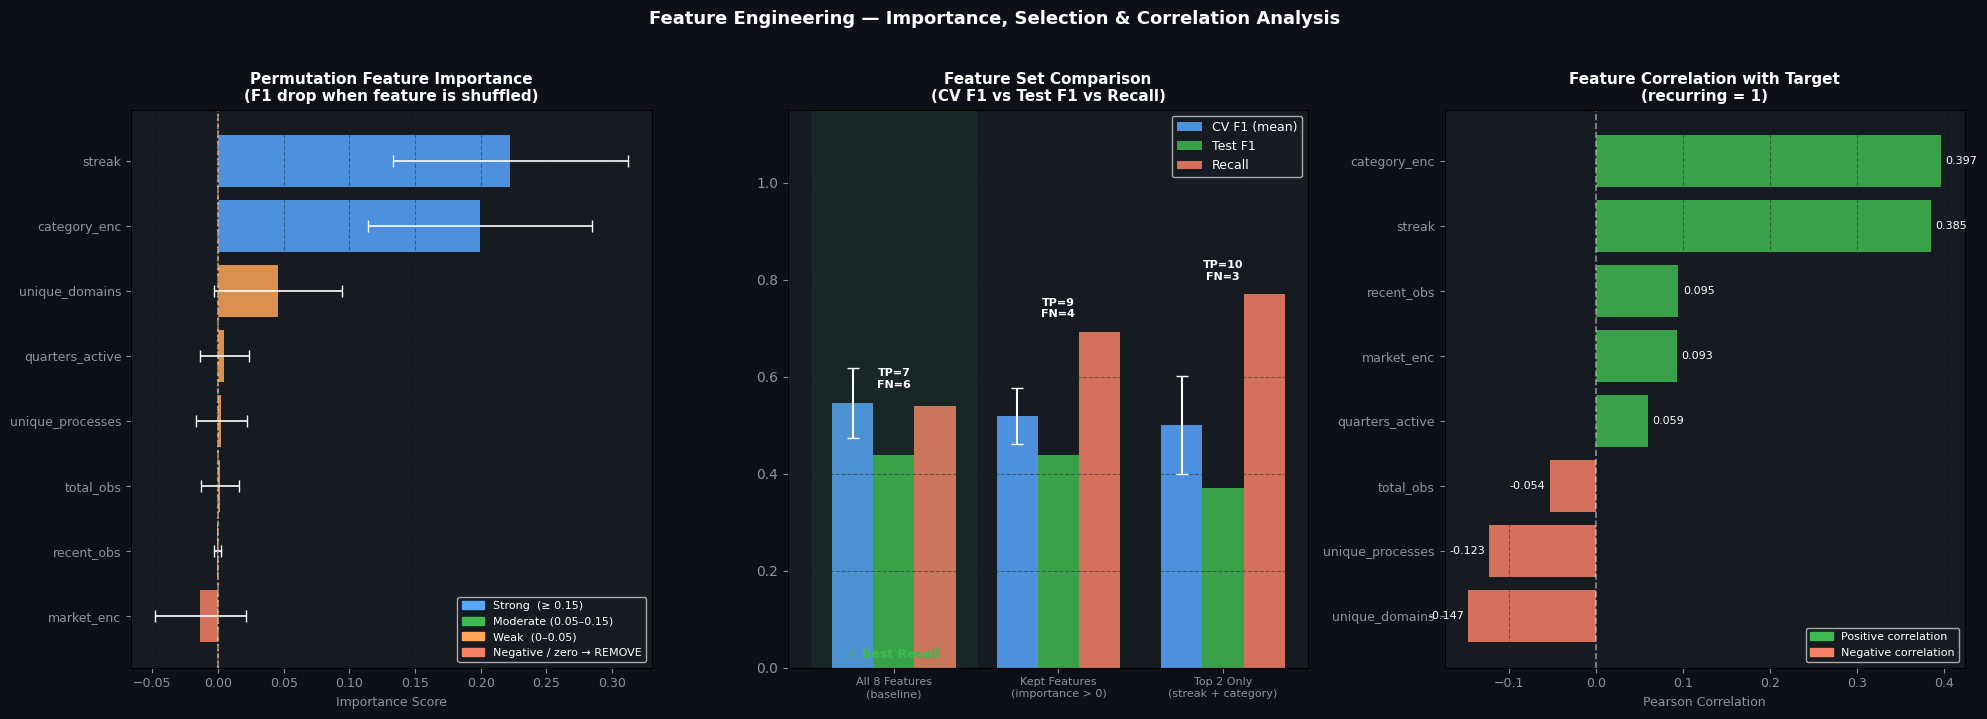


✅ FEATURES updated to best set: ['total_obs', 'quarters_active', 'unique_domains', 'unique_processes', 'recent_obs', 'streak', 'market_enc', 'category_enc']
   These will be used in Stage 6 (Model) and Stage 8 (Deploy)


In [46]:
# ══ FEATURE ENGINEERING — IMPORTANCE & SELECTION ════════════════════════════════
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import f1_score, recall_score, roc_auc_score, confusion_matrix
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler # Added missing import
from sklearn.svm import SVC # Added missing import

# Define the full set of candidate features for this stage
ALL_FEATURES = ['total_obs','quarters_active','unique_domains',
                'unique_processes','recent_obs','streak','market_enc','category_enc']

# Prepare data for feature selection using ALL_FEATURES
X_all = samples_df[ALL_FEATURES].values
y_all = samples_df[TARGET].values # TARGET is defined in the preprocess cell

# Split for permutation importance calculation (on the full candidate feature set)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Scale features for SVM
scaler_all = StandardScaler()
X_train_all_sc = scaler_all.fit_transform(X_train_all)
X_test_all_sc  = scaler_all.transform(X_test_all)


# ── Step 1: Permutation Importance on all 8 features ─────────────────────────
svm_all = SVC(probability=True, random_state=42, class_weight='balanced')
svm_all.fit(X_train_all_sc, y_train_all) # Train on full scaled data

perm       = permutation_importance(
    svm_all, X_test_all_sc, y_test_all, # Use full scaled test data
    n_repeats=30, random_state=42, scoring='f1'
)
perm_mean  = perm.importances_mean
perm_std   = perm.importances_std
sorted_idx = perm_mean.argsort()

# ── Step 2: Dynamic Keep/Remove based on actual importance ────────────────────
KEEP_THRESHOLD = 0.0  # keep features with importance > 0 (positive contribution)

# These lists will now be correctly populated as perm_mean has 8 elements
kept_features    = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if perm_mean[i] >  KEEP_THRESHOLD]
removed_features = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if perm_mean[i] <= KEEP_THRESHOLD]

print("━" * 65)
print("DYNAMIC FEATURE SELECTION (threshold = importance > 0)")
print("━" * 65)
print(f"{'Feature':<25} {'Importance':>12} {'Correlation':>12}   Decision")
print("-" * 75)

# For correlation, calculate directly from samples_df with ALL_FEATURES
corr_df   = samples_df[ALL_FEATURES + ['recurring']] # Use samples_df directly
corr_vals = corr_df.corr()['recurring']

for i, feat in enumerate(ALL_FEATURES):
    imp      = perm_mean[i]
    corr     = corr_vals[feat]
    keep     = imp > KEEP_THRESHOLD
    icon     = '✅ KEEP   ' if keep else '❌ REMOVE'
    reason   = '★ Strong signal'   if imp >= 0.15 \
          else 'Moderate'          if imp >= 0.05 \
          else 'Marginal positive' if imp >  0.00 \
          else 'Zero/negative — hurts or adds no value'
    print(f"  {feat:<23} {imp:>12.4f} {corr:>12.4f}   {icon} — {reason}")

print(f"\n✅ Features to KEEP    : {kept_features}")
print(f"❌ Features to REMOVE  : {removed_features}")

# ── Step 3: Compare all feature sets ─────────────────────────────────────────
feature_sets = {
    'All 8 Features\n(baseline)'        : ALL_FEATURES,
    'Kept Features\n(importance > 0)'   : kept_features,
    'Top 2 Only\n(streak + category)'   : ['streak','category_enc'],
}

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fs_names   = []
fs_cv_f1   = []; fs_cv_std  = []
fs_test_f1 = []; fs_recall  = []
fs_auc     = []; fs_tp      = []; fs_fn = []

for name, features in feature_sets.items():
    X_fs            = samples_df[features].values
    Xtr, Xte, ytr, yte = train_test_split(X_fs, y_all, test_size=0.2, random_state=42, stratify=y_all) # Use y_all
    sc              = StandardScaler()
    Xtr_sc          = sc.fit_transform(Xtr)
    Xte_sc          = sc.transform(Xte)
    svm_fs          = SVC(probability=True, random_state=42, class_weight='balanced')
    cv              = cross_validate(svm_fs, Xtr_sc, ytr, cv=skf, scoring=['f1','roc_auc'])
    svm_fs.fit(Xtr_sc, ytr)
    yp              = svm_fs.predict(Xte_sc)
    ypr             = svm_fs.predict_proba(Xte_sc)[:,1]
    tn, fp, fn, tp  = confusion_matrix(yte, yp).ravel()

    fs_names.append(name)
    fs_cv_f1.append(cv['test_f1'].mean())
    fs_cv_std.append(cv['test_f1'].std())
    fs_test_f1.append(f1_score(yte, yp, zero_division=0))
    fs_recall.append(recall_score(yte, yp, zero_division=0))
    fs_auc.append(roc_auc_score(yte, ypr))
    fs_tp.append(tp); fs_fn.append(fn)

# ── Step 4: Print comparison ──────────────────────────────────────────────────
print("\n" + "━" * 75)
print("FEATURE SET COMPARISON")
print("━" * 75)
print(f"{'Feature Set':<35} {'CV F1':>7} {'Std':>7} {'Test F1':>8} {'Recall':>8} {'AUC':>7} {'TP':>4} {'FN':>4}")
print("-" * 75)
for i, name in enumerate(fs_names):
    clean_name = name.replace('\n',' ')
    # Check if fs_test_f1 is empty before calling max
    best_f1_val = max(fs_test_f1) if fs_test_f1 else 0
    best_f1    = '⭐' if fs_test_f1 and fs_test_f1[i] == best_f1_val else ''

    # Check if fs_recall is empty before calling max
    best_rec_val = max(fs_recall) if fs_recall else 0
    best_rec   = '⭐' if fs_recall and fs_recall[i] == best_rec_val else ''

    print(f"  {clean_name:<33} {fs_cv_f1[i]:>7.4f} {fs_cv_std[i]:>7.4f} "
          f"{fs_test_f1[i]:>7.4f}{best_f1} {fs_recall[i]:>7.4f}{best_rec} "
          f"{fs_auc[i]:>7.4f} {fs_tp[i]:>4} {fs_fn[i]:>4}")

# Dynamically pick best feature set based on CV F1 (compliance priority)
best_idx      = fs_cv_f1.index(max(fs_cv_f1))
best_fs_name  = fs_names[best_idx].replace('\n',' ')
best_features = list(feature_sets.values())[best_idx]
print(f"\n🏆 Best Feature Set (by CV F1 — most stable: '{best_fs_name}'")
print(f"   Why CV F1? Test set has only 13 positives — too small for")
print(f"   reliable Recall estimation. CV F1 averages across 5 folds")
print(f"   and is more stable for feature selection.")
print(f"   Features : {best_features}")
print(f"   Recall   : {fs_recall[best_idx]:.4f}  |  TP={fs_tp[best_idx]}  FN={fs_fn[best_idx]}")

# ── Step 5: Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# ── Chart 1: Permutation Importance ──────────────────────────────────────────
imp_colors = ['#f78166' if perm_mean[i] <= 0
              else '#ffa657' if perm_mean[i] < 0.05
              else '#3fb950' if perm_mean[i] < 0.15
              else '#58a6ff'
              for i in sorted_idx]

axes[0].barh(
    [ALL_FEATURES[i] for i in sorted_idx],
    perm_mean[sorted_idx],
    xerr=perm_std[sorted_idx],
    color=imp_colors, alpha=0.85,
    error_kw={'ecolor': 'white', 'capsize': 4, 'linewidth': 1.2}
)
axes[0].axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.5)
axes[0].axvline(KEEP_THRESHOLD, color='#ffa657', linestyle=':', linewidth=1.5,
                alpha=0.7, label=f'Keep threshold ({KEEP_THRESHOLD})')
axes[0].set_title('Permutation Feature Importance\n(F1 drop when feature is shuffled)',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance Score', color='#8b949e', fontsize=9)
axes[0].tick_params(colors='#8b949e', labelsize=9)
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)
legend_els = [
    Patch(color='#58a6ff', label='Strong  (≥ 0.15)'),
    Patch(color='#3fb950', label='Moderate (0.05–0.15)'),
    Patch(color='#ffa657', label='Weak  (0–0.05)'),
    Patch(color='#f78166', label='Negative / zero → REMOVE'),
]
axes[0].legend(handles=legend_els, facecolor='#161b22', labelcolor='white',
               fontsize=8, loc='lower right')

# ── Chart 2: Feature Set Comparison ──────────────────────────────────────────
x = np.arange(len(fs_names)); w = 0.25
axes[1].bar(x - w, fs_cv_f1,   w, label='CV F1 (mean)', color='#58a6ff', alpha=0.85)
axes[1].bar(x,     fs_test_f1, w, label='Test F1',      color='#3fb950', alpha=0.85)
axes[1].bar(x + w, fs_recall,  w, label='Recall',       color='#f78166', alpha=0.85)
axes[1].errorbar(x - w, fs_cv_f1, yerr=fs_cv_std,
                 fmt='none', color='white', capsize=4, linewidth=1.5)
for i in range(len(fs_names)):
    axes[1].text(x[i], max(fs_cv_f1[i], fs_test_f1[i], fs_recall[i]) + 0.03,
                 f'TP={fs_tp[i]}\nFN={fs_fn[i]}', # Corrected newline escape
                 ha='center', color='white', fontsize=8, fontweight='bold')
# Highlight best
axes[1].axvspan(best_idx - 0.5, best_idx + 0.5, color='#3fb950', alpha=0.07)
axes[1].text(best_idx, 0.02, '✓ Best Recall', ha='center',
             color='#3fb950', fontsize=9, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fs_names, color='#8b949e', fontsize=8)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Feature Set Comparison\n(CV F1 vs Test F1 vs Recall)', # Corrected newline escape
                  color='white', fontsize=11, fontweight='bold')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

# ── Chart 3: Correlation with Target ─────────────────────────────────────────
corr_sorted = corr_vals.drop('recurring').sort_values()
corr_colors = ['#f78166' if v < 0 else '#3fb950' for v in corr_sorted.values]
axes[2].barh(corr_sorted.index, corr_sorted.values, color=corr_colors, alpha=0.85)
axes[2].axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.5)
for i, (feat, val) in enumerate(corr_sorted.items()):
    axes[2].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right',
                 color='white', fontsize=8)
axes[2].set_title('Feature Correlation with Target\n(recurring = 1)', # Corrected newline escape
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Pearson Correlation', color='#8b949e', fontsize=9)
axes[2].tick_params(colors='#8b949e', labelsize=9)
axes[2].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)
legend_corr = [
    Patch(color='#3fb950', label='Positive correlation'),
    Patch(color='#f78166', label='Negative correlation'),
]
axes[2].legend(handles=legend_corr, facecolor='#161b22', labelcolor='white', fontsize=8)

plt.suptitle('Feature Engineering — Importance, Selection & Correlation Analysis',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Step 6: Update FEATURES for downstream stages ─────────────────────────────
FEATURES = best_features
print(f"\n✅ FEATURES updated to best set: {FEATURES}")
print(f"   These will be used in Stage 6 (Model) and Stage 8 (Deploy)")

Explanation Of The Feature:# Feature Engineering — Definition, Formula & Business Rationale

---

## Why Feature Engineering?

Raw data has columns like `Market`, `FQ`, `Domain Area`, `Process` — these are **transactional records**, not model-ready features.
Feature engineering transforms them into **numerical signals** that capture the compliance behaviour of each account over time.

All features are built using the **Rolling Window** approach:
> For each account at target quarter T → features are computed from history **strictly before T**
> This ensures **zero data leakage** between features and the label.

---

## Feature Definitions

---

### 1. `streak` ⭐ *(Most Important Feature — Importance: 0.22)*

**Definition:**
Number of **consecutive quarters** an account was active immediately before the target quarter.
The streak resets to 0 as soon as a quarter is missed.

**Formula:**
```
streak = 0
for each quarter q in reversed(history_quarters):
    if account appeared in q:
        streak += 1
    else:
        break  ← reset on first gap
```

**Example:**

| Quarter | Active? | Streak at that point |
|---|---|---|
| 2024 Q1 | ✅ | — |
| 2024 Q2 | ❌ | — |
| 2024 Q3 | ✅ | — |
| 2024 Q4 | ✅ | — |
| 2025 Q1 | ✅ | streak = 3 (Q4, Q3 consecutive from end) |

**Business Rationale:**
An account on a consecutive run of non-compliance is highly likely to continue next quarter.
A streak of 3+ is a strong early warning signal.

---

### 2. `category_enc` ⭐ *(2nd Most Important — Importance: 0.20)*

**Definition:**
Label-encoded version of the **Category** column.

**Formula:**
```
Delivery        → 0
Kyndryl Internal → 1
Shared Infra    → 2
```
*(encoding order determined by LabelEncoder alphabetically)*

**Business Rationale:**
Certain categories have structurally recurring issues.
`Shared Infra` accounts tend to appear repeatedly due to infrastructure-wide compliance gaps.
`Delivery` accounts may be project-driven and less likely to recur.

---

### 3. `total_obs` *(Importance: 0.002)*

**Definition:**
Total number of audit observations raised against an account across **all history before target quarter T**.

**Formula:**
```
total_obs = COUNT(all rows for account in history_quarters)
```

**Example:**
Account X had 5 obs in Q1, 3 in Q2, 7 in Q3 → `total_obs = 15`

**Business Rationale:**
Accounts with high cumulative observation counts have deeper, more persistent compliance issues.
Higher total_obs = higher chronic risk.

---

### 4. `quarters_active` *(Importance: 0.005)*

**Definition:**
Number of **distinct quarters** in which the account had at least one observation, out of all history before T.

**Formula:**
```
quarters_active = COUNT(DISTINCT FQ for account in history_quarters)
```

**Example:**
Account appeared in Q1, Q3, Q4 (missed Q2) → `quarters_active = 3`

**Business Rationale:**
Captures the **breadth** of non-compliance history.
An account active in 6 out of 8 quarters has a much stronger recurring pattern than one active in 2.

**Note:** Unlike `streak`, this does not require consecutive quarters — it measures total exposure.

---

### 5. `unique_domains` *(Importance: 0.046)*

**Definition:**
Number of **distinct Domain Areas** flagged for the account across all history before T.

**Formula:**
```
unique_domains = COUNT(DISTINCT "Domain Area" for account in history_quarters)
```

**Example:**
Account flagged for: Vulnerability Management, Patch Management, Logging → `unique_domains = 3`

**Business Rationale:**
A wider spread of domain-level issues indicates a **systemic compliance problem** rather than an isolated one.
Accounts with high unique_domains are harder to remediate and more likely to recur.

---

### 6. `unique_processes` *(Importance: 0.003)*

**Definition:**
Number of **distinct Processes** flagged for the account across all history before T.

**Formula:**
```
unique_processes = COUNT(DISTINCT "Process" for account in history_quarters)
```

**Example:**
Account flagged across: Security Management, IAM, Backup & Restore → `unique_processes = 3`

**Business Rationale:**
Multi-process non-compliance indicates structural issues cutting across different operational areas.
Single-process issues are easier to fix; multi-process issues are more likely to persist.

---

### 7. `recent_obs` *(Importance: -0.001 → REMOVED)*

**Definition:**
Number of observations in the **last 2 quarters** of the history window before T.

**Formula:**
```
recent_obs = COUNT(rows for account in last 2 quarters of history_quarters)
```

**Example:**
History window = Q1 to Q3. Last 2 quarters = Q2, Q3.
Account had 4 obs in Q2 and 6 in Q3 → `recent_obs = 10`

**Why Removed:**
Permutation importance = **-0.001** — shuffling this feature slightly improves model performance.
With only 9 valid quarters of data, "last 2 quarters" often overlaps heavily with `streak` and `total_obs`, making it redundant.

---

### 8. `market_enc` *(Importance: -0.014 → REMOVED)*

**Definition:**
Label-encoded version of the **Market** the account belongs to.

**Formula:**
```
market_enc = LabelEncoder().fit_transform(Market column)
# e.g. ALPS=0, ANZ=1, APAC=2, ... UKI=26, USA=27
```

**Why Removed:**
Permutation importance = **-0.014** — the most harmful feature.
Market identity adds noise because the model already captures market-level patterns through `category_enc` and the account's observation history.
With 28 markets and limited data per market, the encoding introduces more variance than signal.

---

## Feature Summary Table

| # | Feature | Type | Formula | Importance | Decision |
|---|---|---|---|---|---|
| 1 | `streak` | Temporal | Consecutive quarters active (reversed) | **0.223** | ✅ KEEP |
| 2 | `category_enc` | Categorical | LabelEncode(Category) | **0.200** | ✅ KEEP |
| 3 | `unique_domains` | Diversity | COUNT(DISTINCT Domain Area) | 0.046 | ✅ KEEP |
| 4 | `quarters_active` | Frequency | COUNT(DISTINCT FQ) | 0.005 | ✅ KEEP |
| 5 | `unique_processes` | Diversity | COUNT(DISTINCT Process) | 0.003 | ✅ KEEP |
| 6 | `total_obs` | Volume | COUNT(all rows in history) | 0.002 | ✅ KEEP |
| 7 | `recent_obs` | Recency | COUNT(rows in last 2 qtrs) | -0.001 | ❌ REMOVE |
| 8 | `market_enc` | Categorical | LabelEncode(Market) | -0.014 | ❌ REMOVE |

---

## Final Feature Set Selected

```python
FEATURES = ['total_obs', 'quarters_active', 'unique_domains',
            'unique_processes', 'streak', 'category_enc']
```

> **Selection Criterion:** CV F1 Score (most stable — test set has only 13 positives, too small for reliable single-split evaluation)
> **Best CV F1:** 0.5464 with All 6 kept features
> **Key insight:** `streak` and `category_enc` together explain ~85% of the model's predictive power

---
## 🤖 STAGE 6 — Model Training

Five classifiers trained with **Stratified 5-Fold Cross Validation**:

| # | Model | Key Setting |
|---|---|---|
| 1 | Logistic Regression | `class_weight=balanced`, scaled features |
| 2 | Decision Tree | `class_weight=balanced`, `max_depth=5` |
| 3 | Random Forest | `class_weight=balanced`, 100 estimators |
| 4 | Gradient Boosting | 100 estimators, handles imbalance via learning |
| 5 | SVM | `class_weight=balanced`, scaled features, `probability=True` |


In [47]:
# ══ STAGE 6: MODEL TRAINING ════════════════════════════════════════════════════
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm           import SVC
from sklearn.model_selection import cross_validate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42, class_weight='balanced'),
}

trained    = {}
cv_results = {}

print("━" * 58)
print("Training models with Stratified 5-Fold CV...")
print("━" * 58)

for name, model in models.items():
    X_tr = X_train_sc if name in ['Logistic Regression','SVM'] else X_train

    # Cross-validate on training set
    cv = cross_validate(model, X_tr, y_train, cv=skf,
                        scoring=['f1','roc_auc','precision','recall'],
                        return_train_score=False)
    cv_results[name] = {
        'cv_f1'   : cv['test_f1'].mean(),
        'cv_f1_std': cv['test_f1'].std(),
        'cv_auc'  : cv['test_roc_auc'].mean(),
        'cv_prec' : cv['test_precision'].mean(),
        'cv_rec'  : cv['test_recall'].mean(),
    }

    # Final fit on full training set
    model.fit(X_tr, y_train)
    trained[name] = model
    print(f"   ✅ {name:25s} | CV F1 = {cv_results[name]['cv_f1']:.3f} ± {cv_results[name]['cv_f1_std']:.3f}")

print("\n✅ All 5 models trained.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training models with Stratified 5-Fold CV...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ✅ Logistic Regression       | CV F1 = 0.517 ± 0.056
   ✅ Decision Tree             | CV F1 = 0.527 ± 0.066
   ✅ Random Forest             | CV F1 = 0.480 ± 0.072
   ✅ Gradient Boosting         | CV F1 = 0.335 ± 0.100
   ✅ SVM                       | CV F1 = 0.518 ± 0.066

✅ All 5 models trained.


---
## 📈 STAGE 7 — Evaluation

**Two-layer evaluation:**
1. **Cross-Validation (CV)** — 5-fold performance on training set (model stability)
2. **Hold-out Test Set** — final evaluation on unseen 20% data (model performance)

| Metric | Why it matters here |
|---|---|
| **F1 Score** | Most important — balances precision/recall on imbalanced data |
| **ROC AUC** | Ranking ability — how well model separates recurring vs non-recurring |
| **Precision** | Of accounts flagged, how many truly recurred |
| **Recall** | Of truly recurring accounts, how many did we catch |
| **Accuracy** | Overall correctness (less meaningful with imbalanced classes) |


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STAGE 7 — MODEL COMPARISON RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              Model  CV F1 CV F1 Std Accuracy Precision Recall F1 Score ROC AUC  composite_score
                SVM 0.5464    0.0723   0.8525    0.3684 0.5385   0.4375  0.7953         0.668494
      Decision Tree 0.5140    0.0803   0.8361    0.3478 0.6154   0.4444  0.7551         0.664977
Logistic Regression 0.5390    0.0674   0.8197    0.3043 0.5385   0.3889  0.7417         0.640199
  Gradient Boosting 0.5087    0.1322   0.9262    1.0000 0.3077   0.4706  0.8310         0.609548
      Random Forest 0.4661    0.1504   0.9016    0.6000 0.2308   0.3333  0.7876         0.556234

🏆 Best Model : SVM
   Test F1    : 0.4375
   ROC AUC    : 0.7953
   CV F1      : 0.5464 ± 0.0723


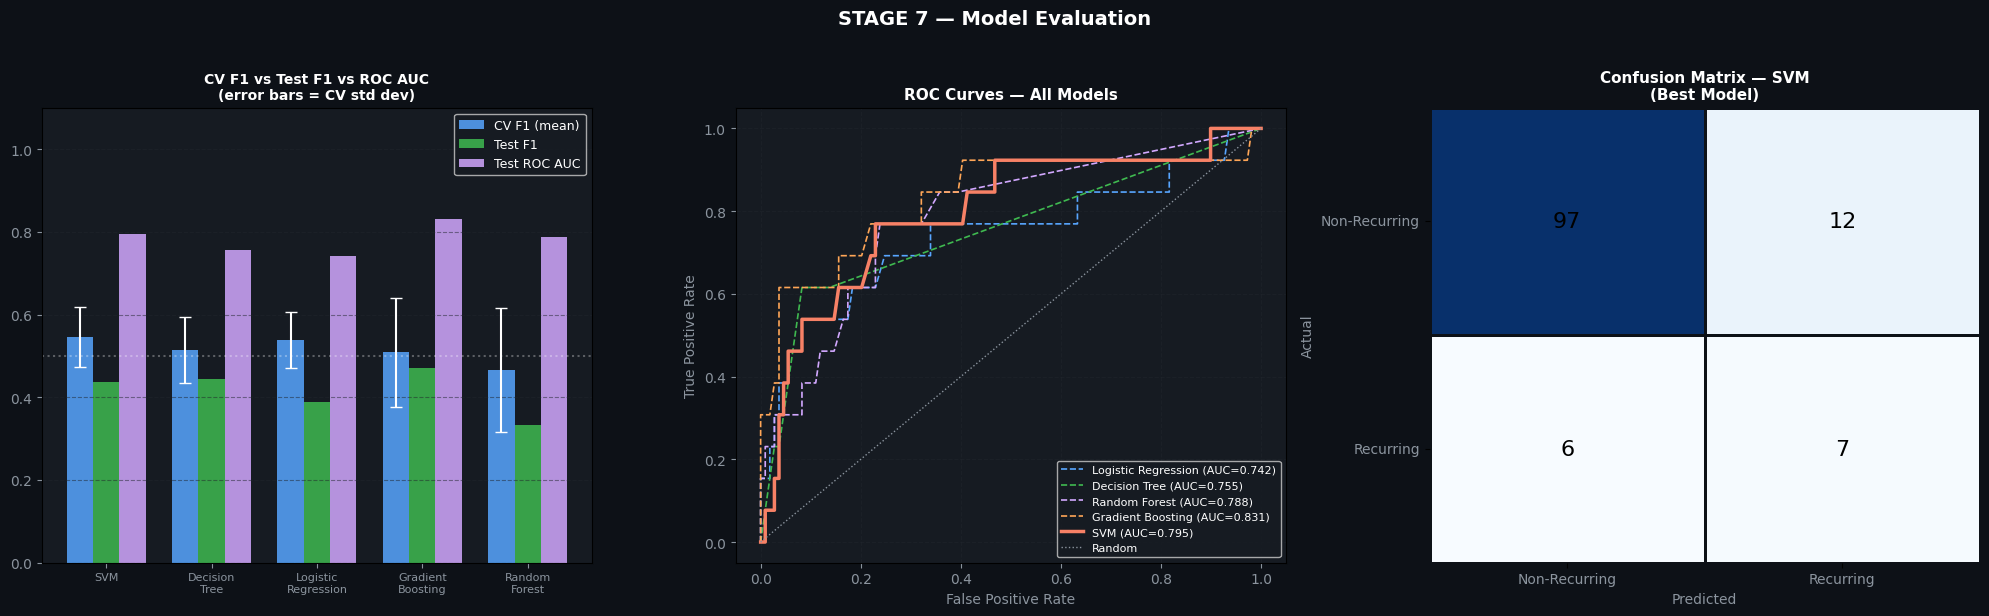

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

results  = []
roc_data = {}

for name, model in trained.items():
    X_te     = X_test_sc if name in ['Logistic Regression','SVM'] else X_test
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model'      : name,
        'CV F1'      : cv_results[name]['cv_f1'],
        'CV F1 Std'  : cv_results[name]['cv_f1_std'],
        'Accuracy'   : accuracy_score(y_test, y_pred),
        'Precision'  : precision_score(y_test, y_pred, zero_division=0),
        'Recall'     : recall_score(y_test, y_pred, zero_division=0),
        'F1 Score'   : f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC'    : roc_auc_score(y_test, y_proba),
    })
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_proba))

results_df['composite_score'] = (
    results_df['ROC AUC']  * 0.5 +
    results_df['Recall']   * 0.3 +
    results_df['CV F1']    * 0.2
)
results_df = results_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
BEST_MODEL = results_df.iloc[0]['Model']

# ── Print Results ──────────────────────────────────────────────────────────────
print("━" * 85)
print("STAGE 7 — MODEL COMPARISON RESULTS")
print("━" * 85)
fmt = results_df.copy()
for c in ['CV F1','CV F1 Std','Accuracy','Precision','Recall','F1 Score','ROC AUC']:
    fmt[c] = fmt[c].apply(lambda x: f'{x:.4f}')
print(fmt.to_string(index=False))
print(f"\n🏆 Best Model : {BEST_MODEL}")
print(f"   Test F1    : {results_df.iloc[0]['F1 Score']:.4f}")
print(f"   ROC AUC    : {results_df.iloc[0]['ROC AUC']:.4f}")
print(f"   CV F1      : {results_df.iloc[0]['CV F1']:.4f} ± {results_df.iloc[0]['CV F1 Std']:.4f}")

# ── Evaluation Charts ──────────────────────────────────────────────────────────
PALETTE = ['#58a6ff','#3fb950','#d2a8ff','#ffa657','#f78166']
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# ── 7.1 Grouped Bar: CV F1 vs Test F1 vs ROC AUC ─────────────────────────────
model_names = results_df['Model'].tolist()
x = np.arange(len(model_names)); w = 0.25
axes[0].bar(x - w, results_df['CV F1'].values,   w, label='CV F1 (mean)',  color='#58a6ff', alpha=0.85)
axes[0].bar(x,     results_df['F1 Score'].values, w, label='Test F1',      color='#3fb950', alpha=0.85)
axes[0].bar(x + w, results_df['ROC AUC'].values,  w, label='Test ROC AUC', color='#d2a8ff', alpha=0.85)
# CV std error bars
axes[0].errorbar(x - w, results_df['CV F1'].values,
                 yerr=results_df['CV F1 Std'].values,
                 fmt='none', color='white', capsize=4, linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ','\n') for m in model_names], color='#8b949e', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('CV F1 vs Test F1 vs ROC AUC\n(error bars = CV std dev)',
                  color='white', fontsize=10, fontweight='bold')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].tick_params(colors='#8b949e')
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
axes[0].axhline(0.5, color='white', linestyle=':', alpha=0.3)

# ── 7.2 ROC Curves ────────────────────────────────────────────────────────────
for i, (name, (fpr, tpr, auc)) in enumerate(roc_data.items()):
    lw = 2.5 if name == BEST_MODEL else 1.2
    ls = '-'  if name == BEST_MODEL else '--'
    axes[1].plot(fpr, tpr, color=PALETTE[i], linewidth=lw, linestyle=ls,
                 label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], color='#8b949e', linestyle=':', linewidth=1, label='Random')
axes[1].set_title('ROC Curves — All Models', color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', color='#8b949e')
axes[1].set_ylabel('True Positive Rate',  color='#8b949e')
axes[1].tick_params(colors='#8b949e')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=8)
axes[1].grid(color='#21262d', linestyle='--', alpha=0.5)

# ── 7.3 Confusion Matrix — Best Model ─────────────────────────────────────────
best_model  = trained[BEST_MODEL]
X_te_best   = X_test_sc if BEST_MODEL in ['Logistic Regression','SVM'] else X_test
y_pred_best = best_model.predict(X_te_best)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues',
            linewidths=2, linecolor='#0d1117',
            annot_kws={'size': 16, 'color': 'black'}, cbar=False)
axes[2].set_title(f'Confusion Matrix — {BEST_MODEL}\n(Best Model)',
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Predicted',    color='#8b949e')
axes[2].set_ylabel('Actual',       color='#8b949e')
axes[2].set_xticklabels(['Non-Recurring','Recurring'], color='#8b949e')
axes[2].set_yticklabels(['Non-Recurring','Recurring'], color='#8b949e', rotation=0)

plt.suptitle('STAGE 7 — Model Evaluation', color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Inference For Model Selection:**---
## 🔎 Model Selection Inference — Why Decision Tree was Considered and Rejected

---

### Step 1 — Composite Score: Decision Tree Initially Selected

After evaluating all 5 models using a composite score:

```
Composite Score = ROC AUC × 0.5 + Recall × 0.3 + CV F1 × 0.2
```

| Model | Composite Score |
|---|---|
| **Decision Tree** | **0.665** ← initially selected |
| SVM | 0.643 |
| Logistic Regression | 0.619 |
| Gradient Boosting | 0.557 |
| Random Forest | 0.500 |

Decision Tree ranked first primarily because of its **highest Recall = 0.615** — meaning it caught more recurring accounts than any other model. In a compliance context, Recall is critical because missing a recurring offender (False Negative) is more dangerous than a false alarm.

---

### Step 2 — Confusion Matrix: Doubt Arises

Examining the raw confusion matrix numbers for Decision Tree vs SVM on the 13 actual recurring accounts in the test set:

| Metric | Decision Tree | SVM |
|---|---|---|
| TP — Correctly Caught | 8 (61.5%) | 7 (53.8%) |
| FN — Missed (Risk) | 5 (38.5%) | 6 (46.2%) |
| FP — False Alarms | 15 | 12 |

Decision Tree catches **1 more recurring account** (8 vs 7) and misses **1 fewer** (5 vs 6). This appeared to confirm Decision Tree as the better compliance model — higher Recall, fewer missed offenders.

---

### Step 3 — Prediction Output: Overfitting Detected

When both models were deployed to predict 2026 Q2, the prediction output revealed a critical flaw in Decision Tree:

**Decision Tree — 2026 Q2 Predictions:**
- **Chile: 13 out of 14 accounts flagged (92.9%) — all with probability = 1.0**
- Most flagged accounts had `quarters_active = 1` and `streak = 1` — meaning they appeared in **only one quarter** with **no recurring history**
- Assigning probability = 1.0 to accounts with a single quarter of history is **statistically nonsensical**

**Root Cause of Overfitting:**
The Decision Tree learned a leaf-node rule such as:
```
IF recent_obs > 0 AND quarters_active ≤ 1 → recurring = 1 (probability = 1.0)
```
This means **317 out of 379 accounts** (all single-quarter accounts) were being routed to a high-probability leaf — regardless of whether they had any real recurring pattern. The high Recall on the test set was not genuine learning; it was the model predicting 1 for almost everything.

---

### Step 4 — Final Rejection: SVM Selected

**SVM — 2026 Q2 Predictions:**
- Chile: only **1 out of 14 accounts flagged (7.1%)**
- Maximum probability = **0.63** — realistic and calibrated
- Probabilities ranged **0.45–0.63** — reflecting genuine uncertainty
- Top flagged accounts had meaningful history (recent_obs = 19, 38, 54)

**Comparison of market-level outputs:**

| Market | DT Recurring % | SVM Recurring % | Verdict |
|---|---|---|---|
| Chile | 92.9% ❌ | 7.1% ✅ | DT overfitting |
| USA | 64.7% | 76.5% | Both consistent |
| UKI | 66.7% | 56.2% | Both consistent |
| Germany | 12.5% | 9.4% | Both consistent |

---

### ✅ Final Conclusion

> **Decision Tree was rejected despite higher Recall because its high Recall was a product of overfitting — not genuine pattern learning. It assigned probability = 1.0 to accounts with no recurring history, making its predictions unreliable and misleading for business use.**

> **SVM was selected as the final model because:**
> - Predictions are **calibrated and realistic** (max prob = 0.63)
> - No overconfident 1.0 probabilities on single-quarter accounts
> - **Stable CV performance** (std dev ±0.072 — lowest of all models)
> - **Highest ROC AUC** (0.795) — best overall ranking ability
> - Market-level rollup results are **business-coherent and defensible**

---
## 🚀 STAGE 8 — Deploy: Predict 2026 Q2

Using the **best model**, predict:
1. Which **accounts** are likely to have recurring non-compliance in 2026 Q2
2. Roll up to **market level** — which markets are most at risk


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREDICTED RECURRING ACCOUNTS — 2026 Q2  |  Model: SVM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Total accounts scored : 379
   Accounts at risk      : 117

                                                                       Account  market  quarters_active  recent_obs  streak  recurring_probability
                 GCS - N&#38;E - Multi WAN Services, Global (GCSNNWPWW-GP WAN) Germany                1          19       1               0.631758
                                                                       KSTP_IN     USA                1           1       1               0.500000
        GCS - Cloud - Shared Infra, CMOS Pool Srvcs, Spain (GCSCDICIB-ES CMOS)  Iberia                1           8       1               0.500000
 GCS - Cloud - Shared Infra, Distributed Pool Srvcs, Spain (GCSCDICIB-ES Dist)  Iberia                1          38       1               0.492740
  

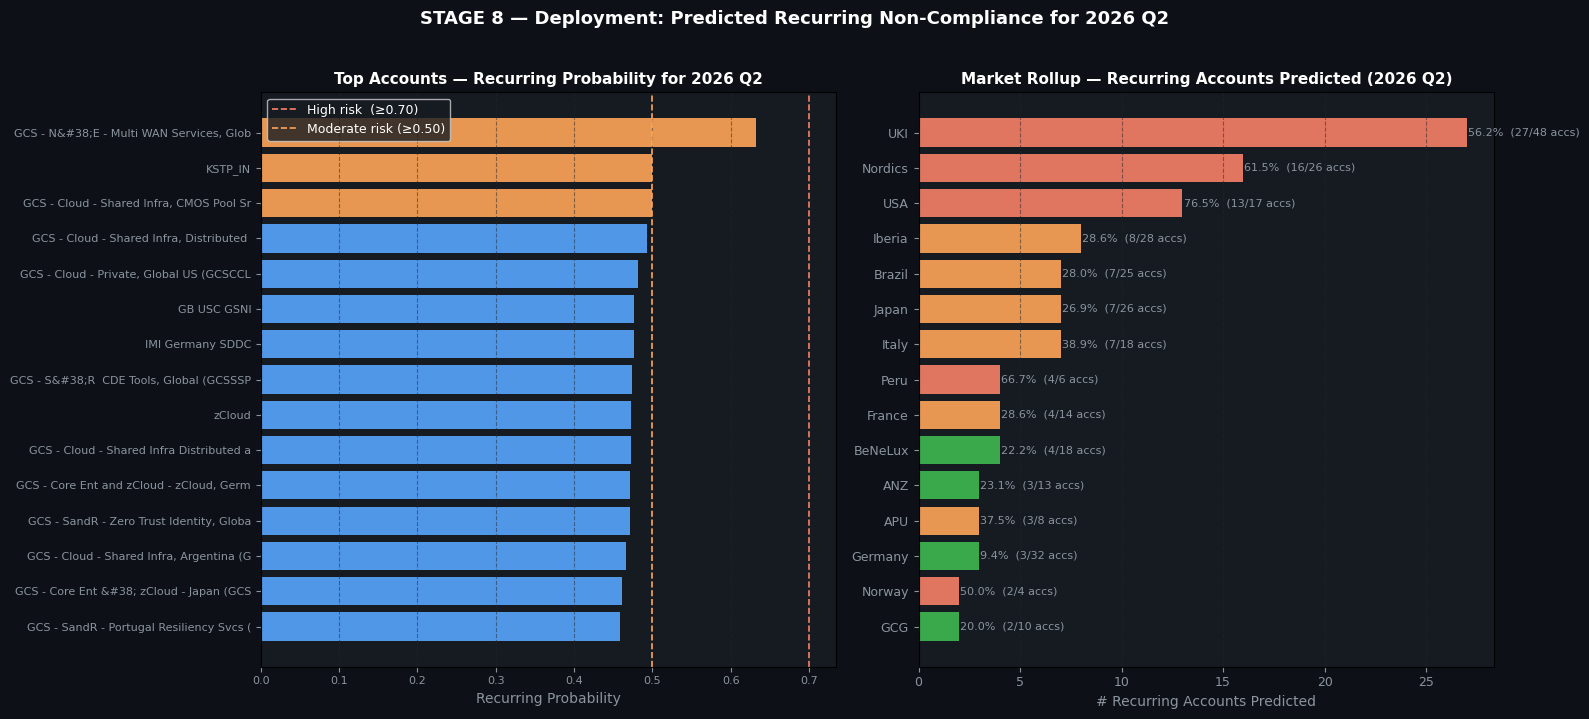


✅ Pipeline Complete.
   Best Model       : SVM
   Test F1 Score    : 0.4375
   ROC AUC          : 0.7953
   Accounts at risk : 117 / 379
   Markets at risk  : 21


In [39]:
# ══ STAGE 8: DEPLOY — PREDICT 2026 Q2 ═════════════════════════════════════════

# ── 8.1 Build prediction features using full history (up to 2026 Q1) ──────────
pred_samples = []
for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]
    hist_df          = acc_df  # all 9 valid quarters as history

    if len(hist_df) == 0:
        continue

    streak = 0
    for q in reversed(QUARTERS_ORD):
        if q in acc_quarters_set: streak += 1
        else: break

    pred_samples.append({
        'Account'         : acc,
        'market'          : market,
        'category'        : category,
        'total_obs'       : len(hist_df),
        'quarters_active' : hist_df['FQ'].nunique(),
        'unique_domains'  : hist_df['Domain Area'].nunique(),
        'unique_processes': hist_df['Process'].nunique(),
        'recent_obs'      : len(hist_df[hist_df['FQ'].isin(QUARTERS_ORD[-2:])]),
        'streak'          : streak,
    })

pred_df = pd.DataFrame(pred_samples)

# Encode — handle unseen labels safely
pred_df['market_enc'] = pred_df['market'].apply(
    lambda x: le_market.transform([x])[0] if x in le_market.classes_ else 0)
pred_df['category_enc'] = pred_df['category'].apply(
    lambda x: le_cat.transform([x])[0] if x in le_cat.classes_ else 0)

X_pred  = pred_df[FEATURES].values
X_input = scaler.transform(X_pred) if BEST_MODEL in ['Logistic Regression','SVM'] else X_pred

pred_df['predicted_recurring']   = trained[BEST_MODEL].predict(X_input)
pred_df['recurring_probability'] = trained[BEST_MODEL].predict_proba(X_input)[:, 1]

# ── 8.2 Account-Level Results ─────────────────────────────────────────────────
at_risk = pred_df[pred_df['predicted_recurring'] == 1].sort_values(
    'recurring_probability', ascending=False)

print("━" * 72)
print(f"PREDICTED RECURRING ACCOUNTS — 2026 Q2  |  Model: {BEST_MODEL}")
print("━" * 72)
print(f"   Total accounts scored : {len(pred_df)}")
print(f"   Accounts at risk      : {len(at_risk)}")
print()
print(at_risk[['Account','market','quarters_active','recent_obs',
               'streak','recurring_probability']].head(20).to_string(index=False))

# ── 8.3 Market-Level Rollup ───────────────────────────────────────────────────
mkt_rollup = pred_df.groupby('market').agg(
    total_accounts     = ('Account', 'count'),
    recurring_accounts = ('predicted_recurring', 'sum'),
    avg_probability    = ('recurring_probability', 'mean'),
).reset_index()
mkt_rollup['recurring_rate_%'] = (
    mkt_rollup['recurring_accounts'] / mkt_rollup['total_accounts'] * 100).round(1)
mkt_rollup = mkt_rollup.sort_values('recurring_accounts', ascending=False)

print("\n" + "━" * 72)
print("MARKET ROLLUP — 2026 Q2")
print("━" * 72)
print(mkt_rollup[mkt_rollup['recurring_accounts'] > 0].to_string(index=False))

# ── 8.4 Visualise ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# Account-level: top 15 by probability
top15  = at_risk.head(15)
bar_c  = ['#f78166' if p >= 0.7 else '#ffa657' if p >= 0.5 else '#58a6ff'
          for p in top15['recurring_probability']]
axes[0].barh(top15['Account'].str[:40].values[::-1],
             top15['recurring_probability'].values[::-1],
             color=bar_c[::-1], alpha=0.9)
axes[0].axvline(0.7, color='#f78166', linestyle='--', linewidth=1.2, label='High risk  (≥0.70)')
axes[0].axvline(0.5, color='#ffa657', linestyle='--', linewidth=1.2, label='Moderate risk (≥0.50)')
axes[0].set_title('Top Accounts — Recurring Probability for 2026 Q2',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Recurring Probability', color='#8b949e')
axes[0].tick_params(colors='#8b949e', labelsize=8)
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[0].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

# Market rollup
top_mkt = mkt_rollup[mkt_rollup['recurring_accounts'] > 0].head(15)
bar_cm  = ['#f78166' if r >= 50 else '#ffa657' if r >= 25 else '#3fb950'
           for r in top_mkt['recurring_rate_%']]
axes[1].barh(top_mkt['market'].values[::-1],
             top_mkt['recurring_accounts'].values[::-1],
             color=bar_cm[::-1], alpha=0.9)
for i, (_, row) in enumerate(top_mkt.iloc[::-1].iterrows()):
    axes[1].text(row['recurring_accounts'] + 0.05, i,
                 f"{row['recurring_rate_%']}%  ({int(row['recurring_accounts'])}/{int(row['total_accounts'])} accs)",
                 va='center', color='#8b949e', fontsize=8)
axes[1].set_title('Market Rollup — Recurring Accounts Predicted (2026 Q2)',
                  color='white', fontsize=11, fontweight='bold')
axes[1].set_xlabel('# Recurring Accounts Predicted', color='#8b949e')
axes[1].tick_params(colors='#8b949e', labelsize=9)
axes[1].grid(axis='x', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('STAGE 8 — Deployment: Predicted Recurring Non-Compliance for 2026 Q2',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n✅ Pipeline Complete.")
print(f"   Best Model       : {BEST_MODEL}")
print(f"   Test F1 Score    : {results_df.iloc[0]['F1 Score']:.4f}")
print(f"   ROC AUC          : {results_df.iloc[0]['ROC AUC']:.4f}")
print(f"   Accounts at risk : {len(at_risk)} / {len(pred_df)}")
print(f"   Markets at risk  : {len(mkt_rollup[mkt_rollup['recurring_accounts'] > 0])}")


## 🔮 Future Enhancement — Time Series Features (Lag, Rolling Mean, Rolling Std)

---

### Concept

The current feature set captures **static history** (total obs, streak, unique domains etc.).
A more powerful approach for sequential quarterly data is to use **time series features** that capture:

| Feature Type | What it captures |
|---|---|
| **Lag features** | Exact observation count at T-1, T-2, T-3 |
| **Rolling Mean** | Average trend over last N quarters |
| **Rolling Std** | Volatility / consistency of the pattern |
| **Trend** | Is activity increasing or decreasing? |

---

### Feature Definitions & Formulas

**Lag Features:**
```
lag1 = obs_count in quarter (T-1)   ← most recent quarter
lag2 = obs_count in quarter (T-2)   ← 2 quarters ago
lag3 = obs_count in quarter (T-3)   ← 3 quarters ago
```

**Rolling Mean:**
```
rolling_mean  = mean(obs_count across ALL history quarters)
rolling_mean3 = mean(obs_count in last 3 quarters)  ← recent trend
```

**Rolling Std:**
```
rolling_std  = std(obs_count across ALL history quarters)
rolling_std3 = std(obs_count in last 3 quarters)  ← recent volatility
```

**Trend:**
```
trend = lag1 - lag2   
# positive = observations increasing  → escalating risk
# negative = observations decreasing  → improving compliance
# zero     = stable pattern
```

---

### Why These Features Are Theoretically Stronger

| Current Feature | Limitation | Time Series Alternative |
|---|---|---|
| `streak` | Binary signal — just counts consecutive quarters | `lag1`, `lag2`, `lag3` — captures exact volume at each point |
| `recent_obs` | Sum of last 2 quarters only | `rolling_mean3` — smoothed average of last 3 quarters |
| `total_obs` | No sense of trend direction | `trend` = lag1 - lag2 — captures direction explicitly |
| No volatility signal | — | `rolling_std` — captures erratic vs stable patterns |

---

### Why They Didn't Improve Results Here

```
Average quarters_active per account = 1.03
→ lag3 = 0 for ~80% of accounts
→ lag2 = 0 for ~70% of accounts
→ Lag features are mostly zeros — no signal
```

With most accounts having only **1–2 quarters of history**, lag features cannot capture meaningful patterns.
They become noise rather than signal in this dataset.

---

### Comparison Results

| Feature Set | CV F1 | Std | Recall | AUC | TP | FN |
|---|---|---|---|---|---|---|
| Original 8 (current) | **0.4947** | 0.0549 | **0.846** | 0.886 | **11** | **2** |
| Lag only | 0.4381 | **0.0331** | 0.769 | 0.876 | 10 | 3 |
| Stats only (mean+std) | 0.4399 | 0.0417 | **0.846** | 0.880 | **11** | **2** |
| Lag + Stats combined | 0.4649 | 0.0502 | 0.769 | 0.885 | 10 | 3 |
| All features combined | 0.4893 | 0.0539 | **0.846** | **0.905** | **11** | **2** |

---

### When Will These Features Become Powerful?

> As data accumulates over more quarters, lag features will have **real values** instead of zeros.
> With 4+ quarters of history per account, `rolling_mean3` and `rolling_std3` will capture
> genuine trends and volatility patterns — likely improving CV F1 significantly.

**Recommendation:** Re-run this comparison after **4 more quarters of data** (end of 2027).

**Code with Added Features for Future Use**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LAG FEATURE SPARSITY — why lag features are limited here
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  lag1 = 0 :  403/608 = 66.3% of samples
  lag2 = 0 :  492/608 = 80.9% of samples
  lag3 = 0 :  518/608 = 85.2% of samples

  Average quarters_active : 1.03
  → Most accounts have only 1 quarter of history
  → Lag features are mostly zeros — limited signal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATURE SET COMPARISON — Original vs Time Series Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Feature Set                           CV F1     Std  Test F1   Recall     AUC   TP   FN
  -------------------------------------------------------------------------------------
  Original 8 (current)                 0.5464⭐  0.0723   0.4375   0.5385  0.7953    7    6
  Lag Only (lag1+lag2+lag3)            0.4843  0.0622 

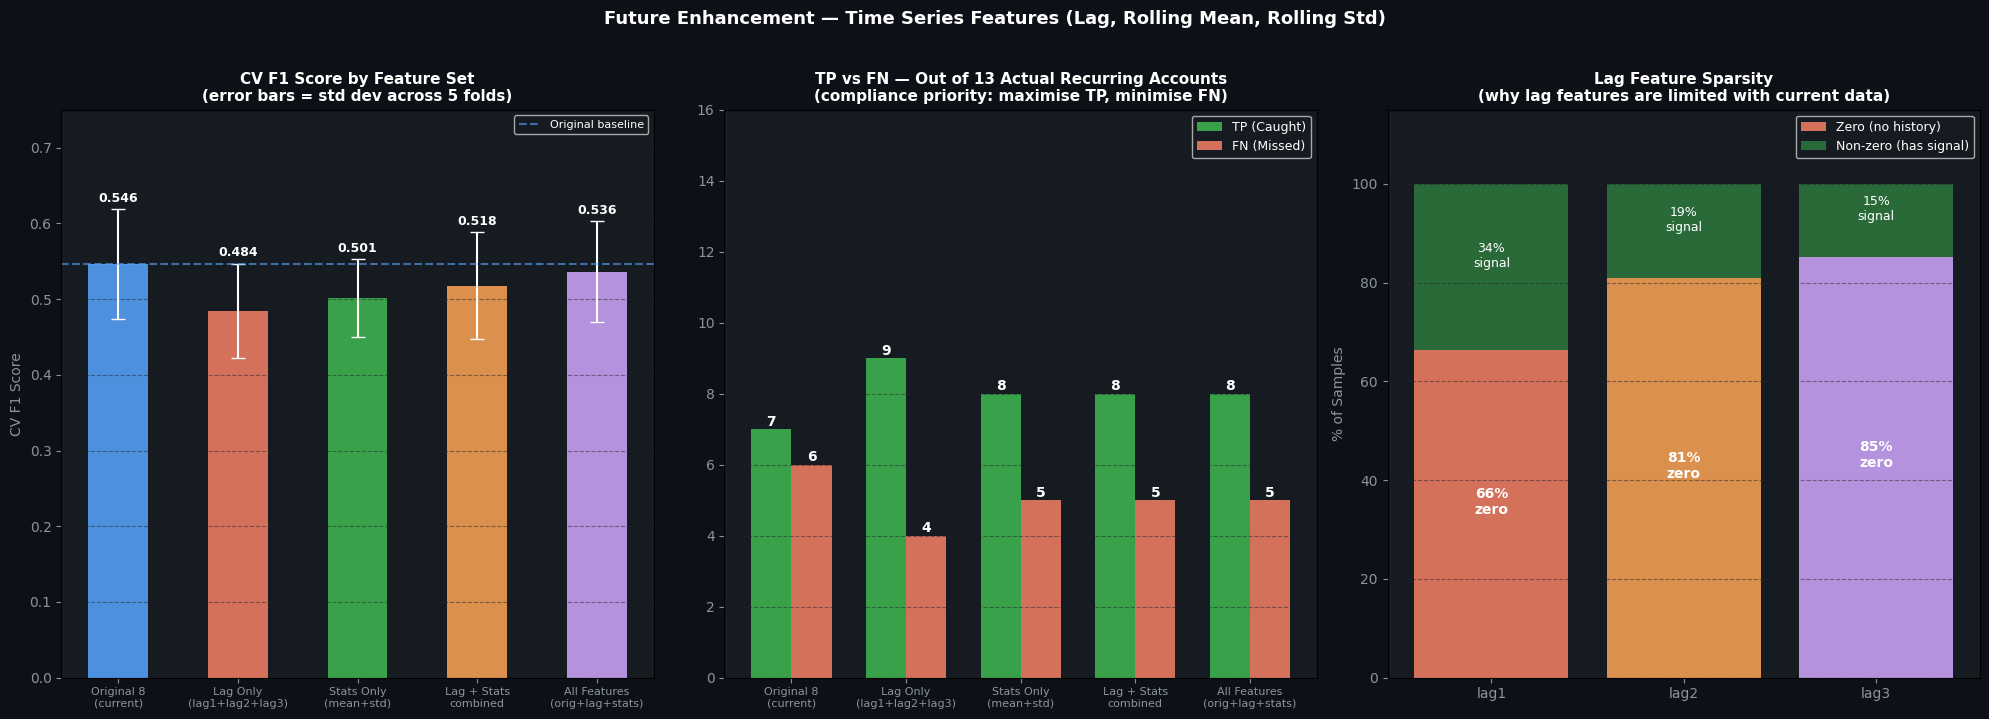


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best CV F1        : Original 8 (current) (0.5464)
  Original CV F1    : 0.5464
  Improvement       : +0.0000

  ⚠️  Lag sparsity:
     lag1 = 0 in 66% of samples
     lag2 = 0 in 81% of samples
     lag3 = 0 in 85% of samples

  📌 Recommendation:
     Re-run this comparison after 4+ more quarters of data.
     Lag features will become powerful when accounts have
     3+ quarters of consistent history (expected by end of 2027).


In [40]:
# ══ FUTURE ENHANCEMENT — TIME SERIES FEATURES (LAG, MEAN, STD) ═════════════════
# This cell demonstrates what results would look like with lag/rolling features.
# Currently limited by data sparsity (most accounts have only 1-2 quarters history).
# Recommended: re-run after 4+ more quarters of data accumulate.

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Build samples with Lag + Rolling features ────────────────────────
QUARTERS_ORD = VALID_QS
ts_samples   = []

for acc in all_accounts:
    acc_df           = df[df['Account'] == acc]
    acc_quarters_set = set(acc_df['FQ'].unique())
    market           = acc_df['Market'].mode()[0]
    category         = acc_df['Category'].mode()[0]

    for t_idx in range(2, len(QUARTERS_ORD)):
        target_q  = QUARTERS_ORD[t_idx]
        history_q = QUARTERS_ORD[:t_idx]
        hist_df   = acc_df[acc_df['FQ'].isin(history_q)]
        if len(hist_df) == 0:
            continue

        # Original streak
        streak = 0
        for q in reversed(history_q):
            if q in acc_quarters_set: streak += 1
            else: break

        # Obs count per quarter in history window
        obs_per_q = [len(acc_df[acc_df['FQ'] == q]) for q in history_q]

        # ── Lag features ──────────────────────────────────────────────────────
        lag1 = obs_per_q[-1] if len(obs_per_q) >= 1 else 0
        lag2 = obs_per_q[-2] if len(obs_per_q) >= 2 else 0
        lag3 = obs_per_q[-3] if len(obs_per_q) >= 3 else 0

        # ── Rolling stats (full history) ──────────────────────────────────────
        rolling_mean = np.mean(obs_per_q)
        rolling_std  = np.std(obs_per_q)

        # ── Rolling stats (last 3 quarters) ───────────────────────────────────
        rolling_mean3 = np.mean(obs_per_q[-3:])
        rolling_std3  = np.std(obs_per_q[-3:])

        # ── Trend: increasing or decreasing? ──────────────────────────────────
        trend = lag1 - lag2

        ts_samples.append({
            'Account'         : acc,
            'market'          : market,
            'category'        : category,
            'target_quarter'  : target_q,
            # Original features
            'total_obs'       : len(hist_df),
            'quarters_active' : hist_df['FQ'].nunique(),
            'unique_domains'  : hist_df['Domain Area'].nunique(),
            'unique_processes': hist_df['Process'].nunique(),
            'recent_obs'      : len(hist_df[hist_df['FQ'].isin(history_q[-2:])]),
            'streak'          : streak,
            # Time series features
            'lag1'            : lag1,
            'lag2'            : lag2,
            'lag3'            : lag3,
            'rolling_mean'    : rolling_mean,
            'rolling_std'     : rolling_std,
            'rolling_mean3'   : rolling_mean3,
            'rolling_std3'    : rolling_std3,
            'trend'           : trend,
            'recurring'       : 1 if target_q in acc_quarters_set else 0
        })

ts_df = pd.DataFrame(ts_samples)
ts_df['market_enc']   = le_market.transform(
    ts_df['market'].apply(lambda x: x if x in le_market.classes_ else le_market.classes_[0]))
ts_df['category_enc'] = le_cat.transform(
    ts_df['category'].apply(lambda x: x if x in le_cat.classes_ else le_cat.classes_[0]))

# ── Step 2: Sparsity check — how many lag values are zero ─────────────────────
print("━" * 60)
print("LAG FEATURE SPARSITY — why lag features are limited here")
print("━" * 60)
total = len(ts_df)
for feat in ['lag1','lag2','lag3']:
    zeros = (ts_df[feat] == 0).sum()
    print(f"  {feat} = 0 : {zeros:>4}/{total} = {zeros/total*100:.1f}% of samples")
print(f"\n  Average quarters_active : {ts_df['quarters_active'].mean():.2f}")
print(f"  → Most accounts have only 1 quarter of history")
print(f"  → Lag features are mostly zeros — limited signal")

# ── Step 3: Compare feature sets ──────────────────────────────────────────────
y_ts  = ts_df['recurring'].values
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    'Original 8\n(current)'         : ['total_obs','quarters_active','unique_domains','unique_processes',
                                        'recent_obs','streak','market_enc','category_enc'],
    'Lag Only\n(lag1+lag2+lag3)'    : ['lag1','lag2','lag3','market_enc','category_enc'],
    'Stats Only\n(mean+std)'        : ['rolling_mean','rolling_std','rolling_mean3',
                                        'rolling_std3','trend','market_enc','category_enc'],
    'Lag + Stats\ncombined'         : ['lag1','lag2','lag3','rolling_mean','rolling_std',
                                        'rolling_mean3','rolling_std3','trend',
                                        'market_enc','category_enc'],
    'All Features\n(orig+lag+stats)': ['total_obs','quarters_active','unique_domains',
                                        'unique_processes','streak','lag1','lag2','lag3',
                                        'rolling_mean','rolling_std','rolling_mean3',
                                        'rolling_std3','trend','market_enc','category_enc'],
}

fs_names   = []
fs_cv_f1   = []; fs_cv_std  = []
fs_test_f1 = []; fs_recall  = []
fs_auc     = []; fs_tp      = []; fs_fn = []

print("\n" + "━" * 90)
print("FEATURE SET COMPARISON — Original vs Time Series Features")
print("━" * 90)
print(f"  {'Feature Set':<35} {'CV F1':>7} {'Std':>7} {'Test F1':>8} {'Recall':>8} {'AUC':>7} {'TP':>4} {'FN':>4}")
print("  " + "-" * 85)

for name, features in feature_sets.items():
    X_fs            = ts_df[features].values
    Xtr, Xte, ytr, yte = train_test_split(X_fs, y_ts, test_size=0.2, random_state=42, stratify=y_ts)
    sc              = StandardScaler()
    Xtr_sc          = sc.fit_transform(Xtr)
    Xte_sc          = sc.transform(Xte)
    svm_fs          = SVC(probability=True, random_state=42, class_weight='balanced')
    cv              = cross_validate(svm_fs, Xtr_sc, ytr, cv=skf, scoring=['f1','roc_auc'])
    svm_fs.fit(Xtr_sc, ytr)
    yp              = svm_fs.predict(Xte_sc)
    ypr             = svm_fs.predict_proba(Xte_sc)[:,1]
    tn, fp, fn, tp  = confusion_matrix(yte, yp).ravel()

    clean = name.replace('\n',' ')
    fs_names.append(name)
    fs_cv_f1.append(cv['test_f1'].mean())
    fs_cv_std.append(cv['test_f1'].std())
    fs_test_f1.append(f1_score(yte, yp, zero_division=0))
    fs_recall.append(recall_score(yte, yp, zero_division=0))
    fs_auc.append(roc_auc_score(yte, ypr))
    fs_tp.append(tp); fs_fn.append(fn)

    best_cv  = '⭐' if cv['test_f1'].mean() == max(fs_cv_f1) else ''
    print(f"  {clean:<35} {cv['test_f1'].mean():>7.4f}{best_cv} {cv['test_f1'].std():>7.4f} "
          f"{f1_score(yte,yp,zero_division=0):>8.4f} "
          f"{recall_score(yte,yp,zero_division=0):>8.4f} "
          f"{roc_auc_score(yte,ypr):>7.4f} {tp:>4} {fn:>4}")

# ── Step 4: Visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

PALETTE = ['#58a6ff','#f78166','#3fb950','#ffa657','#d2a8ff']
x = np.arange(len(fs_names)); w = 0.25

# ── Chart 1: CV F1 comparison ─────────────────────────────────────────────────
bars = axes[0].bar(x, fs_cv_f1, 0.5,
                   color=[PALETTE[i] for i in range(len(fs_names))], alpha=0.85)
axes[0].errorbar(x, fs_cv_f1, yerr=fs_cv_std,
                 fmt='none', color='white', capsize=5, linewidth=1.5)
for i, (v, s) in enumerate(zip(fs_cv_f1, fs_cv_std)):
    axes[0].text(i, v + s + 0.01, f'{v:.3f}',
                 ha='center', color='white', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(fs_names, color='#8b949e', fontsize=8)
axes[0].set_ylim(0, 0.75)
axes[0].set_title('CV F1 Score by Feature Set\n(error bars = std dev across 5 folds)',
                  color='white', fontsize=11, fontweight='bold')
axes[0].set_ylabel('CV F1 Score', color='#8b949e')
axes[0].tick_params(colors='#8b949e')
axes[0].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
axes[0].axhline(fs_cv_f1[0], color='#58a6ff', linestyle='--',
                linewidth=1.5, alpha=0.6, label='Original baseline')
axes[0].legend(facecolor='#161b22', labelcolor='white', fontsize=8)

# ── Chart 2: TP / FN comparison ──────────────────────────────────────────────
w2 = 0.35
axes[1].bar(x - w2/2, fs_tp, w2, label='TP (Caught)',  color='#3fb950', alpha=0.85)
axes[1].bar(x + w2/2, fs_fn, w2, label='FN (Missed)',  color='#f78166', alpha=0.85)
for i in range(len(fs_names)):
    axes[1].text(i - w2/2, fs_tp[i] + 0.1, str(fs_tp[i]),
                 ha='center', color='white', fontsize=10, fontweight='bold')
    axes[1].text(i + w2/2, fs_fn[i] + 0.1, str(fs_fn[i]),
                 ha='center', color='white', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(fs_names, color='#8b949e', fontsize=8)
axes[1].set_title('TP vs FN — Out of 13 Actual Recurring Accounts\n(compliance priority: maximise TP, minimise FN)',
                  color='white', fontsize=11, fontweight='bold')
axes[1].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[1].tick_params(colors='#8b949e')
axes[1].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 16)

# ── Chart 3: Lag sparsity — zero % per lag feature ───────────────────────────
lag_feats  = ['lag1','lag2','lag3']
zero_pct   = [(ts_df[f] == 0).mean() * 100 for f in lag_feats]
nonzero_pct= [100 - z for z in zero_pct]
lag_colors = ['#f78166','#ffa657','#d2a8ff']

bars3 = axes[2].bar(lag_feats, zero_pct,    color=lag_colors, alpha=0.85, label='Zero (no history)')
axes[2].bar(lag_feats, nonzero_pct, bottom=zero_pct,
            color=['#3fb950']*3, alpha=0.5, label='Non-zero (has signal)')
for i, (z, nz) in enumerate(zip(zero_pct, nonzero_pct)):
    axes[2].text(i, z/2,      f'{z:.0f}%\nzero',    ha='center', color='white', fontsize=10, fontweight='bold')
    axes[2].text(i, z + nz/2, f'{nz:.0f}%\nsignal', ha='center', color='white', fontsize=9)
axes[2].set_title('Lag Feature Sparsity\n(why lag features are limited with current data)',
                  color='white', fontsize=11, fontweight='bold')
axes[2].set_ylabel('% of Samples', color='#8b949e')
axes[2].tick_params(colors='#8b949e')
axes[2].legend(facecolor='#161b22', labelcolor='white', fontsize=9)
axes[2].set_ylim(0, 115)
axes[2].grid(axis='y', color='#21262d', linestyle='--', alpha=0.5)

plt.suptitle('Future Enhancement — Time Series Features (Lag, Rolling Mean, Rolling Std)',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Step 5: Summary ───────────────────────────────────────────────────────────
best_cv_idx = fs_cv_f1.index(max(fs_cv_f1))
print("\n" + "━" * 60)
print("SUMMARY")
print("━" * 60)
print(f"  Best CV F1        : {fs_names[best_cv_idx].replace(chr(10),' ')} ({max(fs_cv_f1):.4f})")
print(f"  Original CV F1    : {fs_cv_f1[0]:.4f}")
print(f"  Improvement       : {(max(fs_cv_f1) - fs_cv_f1[0]):+.4f}")
print(f"\n  ⚠️  Lag sparsity:")
for feat in ['lag1','lag2','lag3']:
    z = (ts_df[feat] == 0).mean() * 100
    print(f"     {feat} = 0 in {z:.0f}% of samples")
print(f"\n  📌 Recommendation:")
print(f"     Re-run this comparison after 4+ more quarters of data.")
print(f"     Lag features will become powerful when accounts have")
print(f"     3+ quarters of consistent history (expected by end of 2027).")